## **SNAP Jupyter demo notebook**
**Classical Sentinel-1 IW InSAR — wrapped interferogram, phase unwrapping, and line-of-sight surface displacement**

In summary, this workflow contains:

- The classical end-to-end Sentinel-1 IW InSAR chain in SNAP
- Part 1: produce the wrapped, debursted, topo-phase-removed, Goldstein-filtered interferogram
- Part 2: export the interferogram to SNAPHU format
- Part 3: run SNAPHU externally to unwrap the phase
- Part 4: import the unwrapped phase, convert to displacement, geocode

Complexity: advanced

##### ***About the test data:***

Sentinel-1 IW SLC pair (reference + secondary) covering the same area, same track, with a short temporal baseline. Download from [Copernicus Browser](https://dataspace.copernicus.eu/browser/). Filenames look like `S1A_IW_SLC__1SDV_*`.

Place both `.SAFE` directories under `data/` and update the path variables in the *Configure input paths* cell.

##### ***About SNAPHU:***

Phase unwrapping is done by [SNAPHU](https://web.stanford.edu/group/radar/softwareandlinks/sw/snaphu/), a separate command-line tool that SNAP does **not** bundle. Install it before running Part 3:

- **Linux / macOS**: build from source or install via your package manager (`apt install snaphu` on Debian/Ubuntu, `brew install snaphu` on macOS).
- **Windows**: there is no official Windows build. Use WSL (`apt install snaphu` inside WSL) or a community Windows binary.

Set the `SNAPHU_BIN` variable in the *Configure input paths* cell to the path of the `snaphu` executable.

##### ***Some information on the Python environment:***

In [1]:
import os
import sys
print("Python version: " + sys.version)

import sysconfig
print("Location of esa_snappy package: " + sysconfig.get_paths()['purelib'] + os.sep + "esa_snappy")

Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Location of esa_snappy package: C:\Users\luis_\AppData\Local\Programs\Python\Python313\Lib\site-packages\esa_snappy


##### ***Import Python packages...***

In [2]:
import esa_snappy
from esa_snappy import ProductIO

import snapista
from snapista import Graph
from snapista import Operator

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

##### ***Convenience plot functions:***

In [3]:
def _read_band(product, name, target=1400):
    """Read a band downsampled to ~target px on the long side, in small row strips. Avoids the
    'Cannot construct DataBuffer' that a full-resolution read of a large band triggers."""
    band = product.getBand(name)
    if band is None:
        raise KeyError(f"Band {name!r} not found. Available: {[b.getName() for b in product.getBands()]}")
    w, h = band.getRasterWidth(), band.getRasterHeight()
    dec = max(1, int(max(w, h) / target)); cols = list(range(0, w, dec)); out = []
    for y in range(0, h, 48):
        bh = min(48, h - y)
        buf = np.zeros(w * bh, np.float32); band.readPixels(0, y, w, bh, buf)
        buf.shape = (bh, w); out.append(buf[::dec][:, cols])
    return np.vstack(out)

def plot_band(product, name, title=None, cmap='viridis', vmin=None, vmax=None):
    data = _read_band(product, name)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title or name); fig.colorbar(im, ax=ax)
    plt.show()

def find_band(product, *patterns):
    names = [b.getName() for b in product.getBands()]
    for pat in patterns:
        for n in names:
            if pat.lower() in n.lower():
                return n
    raise KeyError(f"No band matching {patterns!r} found. Available: {names}")

def plot_interferogram(product, *_ignored):
    """Wrapped interferogram phase (from the real i_ifg/q_ifg bands) + coherence, decimated."""
    names = [b.getName() for b in product.getBands()]
    iN = next(n for n in names if n.lower().startswith('i_ifg')
              or (n.lower().startswith('i_') and product.getBand(n).getUnit() == 'real'))
    qN = ('q_' + iN[2:]) if iN.lower().startswith('i_ifg') else iN.replace('i_', 'q_', 1)
    cohN = next((n for n in names if n.lower().startswith('coh')), None)
    i = _read_band(product, iN); q = _read_band(product, qN)
    mask = (i == 0) & (q == 0)
    phi = np.ma.masked_where(mask, np.arctan2(q, i))
    if cohN is None:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(phi, cmap='hsv', vmin=-np.pi, vmax=np.pi)
        ax.set_title('Wrapped interferogram phase [rad]'); fig.colorbar(im, ax=ax)
    else:
        coh = np.ma.masked_where(mask, _read_band(product, cohN))
        print('mean coherence = %.2f' % float(np.ma.mean(coh)))
        fig, axs = plt.subplots(1, 2, figsize=(13, 6))
        im0 = axs[0].imshow(phi, cmap='hsv', vmin=-np.pi, vmax=np.pi)
        axs[0].set_title('Wrapped phase [rad]'); fig.colorbar(im0, ax=axs[0], fraction=0.046)
        im1 = axs[1].imshow(coh, cmap='viridis', vmin=0, vmax=1)
        axs[1].set_title('Coherence'); fig.colorbar(im1, ax=axs[1], fraction=0.046)
    plt.show()

---

### ***Background: the classical IW InSAR chain***

```text
                Reference SLC                  Secondary SLC
                     │                              │
             Apply-Orbit-File              Apply-Orbit-File
                     │                              │
              TOPSAR-Split                  TOPSAR-Split
                     │                              │
                     └───── Back-Geocoding ─────┘
                              │
                  Enhanced-Spectral-Diversity
                              │
                      Interferogram
                  (flat-earth + coherence)
                              │
                      TOPSAR-Deburst
                              │
                    TopoPhaseRemoval
                              │
                  GoldsteinPhaseFiltering
                              │
                     [SnaphuExport]    → SNAPHU (external) → [SnaphuImport]
                                                                   │
                                                         PhaseToDisplacement
                                                                   │
                                                          Terrain-Correction
                                                                   │
                                                                Write
```

Each step in plain English:

1. **Apply-Orbit-File** — download Precise Orbit Ephemerides (POE) and replace the on-board orbit with sub-centimetre-accurate state vectors.
2. **TOPSAR-Split** — pick one subswath and a contiguous burst range.
3. **Back-Geocoding** — use a DEM to predict per-pixel offsets between reference and secondary, and resample the secondary onto the reference grid.
4. **Enhanced-Spectral-Diversity (ESD)** — iteratively refine the azimuth registration at burst overlaps (TOPS-specific).
5. **Interferogram** — compute the complex conjugate multiplication, subtract the flat-earth phase using the orbits and a reference ellipsoid, and produce the coherence band.
6. **TOPSAR-Deburst** — stitch bursts into one continuous subswath strip.
7. **TopoPhaseRemoval** — use the DEM to compute and subtract the topographic phase contribution, leaving (ideally) only the displacement signal.
8. **Goldstein filter** — reduce phase noise to make the next step (unwrapping) work better.
9. **SNAPHU export / unwrap / import** — take the wrapped phase, integrate it into an absolute phase field. This is the step that turns a fringe pattern into a continuous displacement map.
10. **PhaseToDisplacement** — multiply unwrapped phase by `-λ / (4π)` to convert from radians to metres of line-of-sight displacement.
11. **Terrain-Correction** — geocode to a map projection.

> **In this demo** we process a *single burst* and crop the interferogram to a small window so the whole run stays fast. A single burst has no burst overlaps, so **ESD is skipped** (it needs ≥ 2 bursts); for a multi-burst area keep ESD in the chain as drawn above.

---

### ***Configure input paths***

In [4]:
data_dir = os.path.join(os.getcwd(), 'data')
graphs_dir = os.path.join(os.getcwd(), 'graphs')
results_dir = os.path.join(os.getcwd(), 'results')
snaphu_dir = os.path.join(os.getcwd(), 'snaphu')
os.makedirs(graphs_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# --- cached data fetch (public S3 / HTTP; re-runs reuse the local copy) ---
import urllib.request as _urlreq, zipfile as _zip, glob as _glob

def fetch_cached(url, dest_dir):
    """Download `url` into dest_dir unless already present, unzip a .zip, and return the path to
    open (manifest.safe for a .SAFE product, else the downloaded file). Cached for re-runs:
    if the product is already in dest_dir it is NOT downloaded again."""
    os.makedirs(dest_dir, exist_ok=True)
    fname = url.split('/')[-1]
    stem = fname[:-4] if fname.lower().endswith('.zip') else fname
    hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe'))
    if hits:
        print('cached:', os.path.basename(os.path.dirname(hits[0]))); return hits[0]
    local = os.path.join(dest_dir, fname)
    if not os.path.exists(local):
        print('downloading', fname, '...')
        _urlreq.urlretrieve(url, local)
        print('  saved %.0f MB' % (os.path.getsize(local) / 1e6))
    if fname.lower().endswith('.zip'):
        with _zip.ZipFile(local) as z:
            z.extractall(dest_dir)
        hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe'))
        return hits[0] if hits else local
    return local
os.makedirs(snaphu_dir, exist_ok=True)

# Mount Etna IW SLC pair (12-day) on public S3; downloaded on first run (~4 GB each), cached.
_etna = 'https://skywatch-public.s3.us-west-2.amazonaws.com/snap/data/S1/SLC/Etna-DLR/'
reference_slc = fetch_cached(_etna + 'S1A_IW_SLC__1SDV_20140809T165546_20140809T165613_001866_001C20_088B.zip', data_dir)
secondary_slc = fetch_cached(_etna + 'S1A_IW_SLC__1SDV_20140821T165547_20140821T165614_002041_001FC1_8601.zip', data_dir)

# Subswath + burst range
subswath = 'IW1'
polarisation = 'VV'
first_burst = '2'
last_burst = '2'

# --- SNAPHU (Parts 3-4 only): auto-detect native / macOS-Linux build / WSL; Parts 1-2 need none ---
SNAPHU_BIN = 'snaphu'                                    # native binary name / full path
SNAPHU_WSL = '~/snaphu-build/snaphu-v2.0.5/bin/snaphu'   # WSL binary (Windows; built by the setup script)
# macOS/Linux source-build fallback: setup_ds_insar.sh builds here when brew/apt are unavailable
# (and the binary isn't on PATH) -- e.g. a Mac without Homebrew.
SNAPHU_LOCAL = os.path.expanduser('~/snaphu-build/snaphu-v2.0.5/bin/snaphu')
import shutil, subprocess

def _detect_snaphu():
    """Return (mode, exe). mode: 'native' (on PATH), 'local' (macOS/Linux source build),
    'wsl' (Windows via WSL), or None."""
    exe = shutil.which(SNAPHU_BIN)
    if exe:
        return 'native', exe
    if os.path.isfile(SNAPHU_LOCAL) and os.access(SNAPHU_LOCAL, os.X_OK):
        return 'local', SNAPHU_LOCAL                       # macOS/Linux source build (no brew/apt)
    if os.name == 'nt':
        try:
            r = subprocess.run(['wsl', '-e', 'bash', '-lc', f'test -x {SNAPHU_WSL} && echo ok'],
                               capture_output=True, text=True, timeout=30)
            if 'ok' in r.stdout:
                return 'wsl', SNAPHU_WSL
        except Exception:
            pass
    return None, None

snaphu_mode, snaphu_exe = _detect_snaphu()   # ('native'|'local'|'wsl'|None, path|None)
run_snaphu = snaphu_mode is not None
print('snaphu:', snaphu_mode or 'not found (Parts 3-4 will be skipped)')

def _win_to_wsl(p):
    """C:\\a\\b -> /mnt/c/a/b  (deterministic; avoids wslpath mangling backslashes through wsl.exe)."""
    p = os.path.abspath(p)
    return '/mnt/' + p[0].lower() + p[2:].replace('\\', '/')

def run_snaphu_in(folder, args):
    """Run snaphu inside `folder` with list `args`. WSL on Windows; the resolved native/local
    binary (snaphu_exe) otherwise."""
    if snaphu_mode == 'wsl':
        cmd = f"cd '{_win_to_wsl(folder)}' && {SNAPHU_WSL} " + ' '.join(args)
        return subprocess.run(['wsl', '-e', 'bash', '-lc', cmd], capture_output=True, text=True)
    return subprocess.run([snaphu_exe, *args], cwd=folder, capture_output=True, text=True)


def run_graph(g, xml_path):
    """Run a snapista Graph via the gpt CLI on its saved XML, sending gpt's console output to a .log
    file instead of a PIPE. This avoids an intermittent snapista/Windows deadlock where gpt finishes
    the work but a child process keeps the stdout pipe open, so subprocess.communicate() hangs."""
    g.save_graph(xml_path)
    log_path = os.path.splitext(xml_path)[0] + '.log'
    with open(log_path, 'w', encoding='utf-8', errors='replace') as fh:
        rc = subprocess.run(['gpt', xml_path], stdout=fh, stderr=subprocess.STDOUT,
                             stdin=subprocess.DEVNULL).returncode
    if rc != 0:
        tail = open(log_path, encoding='utf-8', errors='replace').read()[-2000:]
        raise RuntimeError('gpt failed (rc=%d) on %s:%s%s'
                           % (rc, os.path.basename(xml_path), os.linesep, tail))
    print('graph OK: %s' % os.path.basename(xml_path))
    return log_path


cached: S1A_IW_SLC__1SDV_20140809T165546_20140809T165613_001866_001C20_088B.SAFE
cached: S1A_IW_SLC__1SDV_20140821T165547_20140821T165614_002041_001FC1_8601.SAFE


snaphu: wsl


---
## ***Part 1 — Wrapped interferogram***
---

We build the full classical chain up to (and including) Goldstein filtering. (Here the chain runs on a single burst and crops to a small AOI for speed.) The output is the wrapped interferogram — a beautiful fringe pattern but still modulo-2π.

In [5]:
def build_iw_branch(g, slc_path, tag):
    g.add_node(operator=Operator('Read', file=slc_path),
               node_id=f'Read_{tag}')
    g.add_node(operator=Operator('Apply-Orbit-File',
                                 orbitType='Sentinel Precise (Auto Download)',
                                 continueOnFail='true'),
               node_id=f'Orbit_{tag}', source=f'Read_{tag}')
    g.add_node(operator=Operator('TOPSAR-Split',
                                 subswath=subswath,
                                 selectedPolarisations=polarisation,
                                 firstBurstIndex=first_burst,
                                 lastBurstIndex=last_burst),
               node_id=f'Split_{tag}', source=f'Orbit_{tag}')
    return f'Split_{tag}'

g_ifg = Graph()
ref_node = build_iw_branch(g_ifg, reference_slc, 'ref')
sec_node = build_iw_branch(g_ifg, secondary_slc, 'sec')

g_ifg.add_node(operator=Operator('Back-Geocoding',
                                 demName='Copernicus 30m Global DEM',
                                 resamplingType='BISINC_5_POINT_INTERPOLATION'),
               node_id='BackGeo', source=[ref_node, sec_node])
# ESD needs >=2 bursts (it operates on burst overlaps); with a single burst we coregister with
# Back-Geocoding only, which is sufficient for this demo.
g_ifg.add_node(operator=Operator('Interferogram',
                                 subtractFlatEarthPhase='true',
                                 subtractTopographicPhase='false',
                                 includeCoherence='true',
                                 cohWinAz='10',
                                 cohWinRg='10'),
               node_id='Ifg', source='BackGeo')
g_ifg.add_node(operator=Operator('TOPSAR-Deburst'),
               node_id='Deburst', source='Ifg')
g_ifg.add_node(operator=Operator('TopoPhaseRemoval',
                                 demName='Copernicus 30m Global DEM'),
               node_id='Topo', source='Deburst')
g_ifg.add_node(operator=Operator('GoldsteinPhaseFiltering', alpha='1.0'),
               node_id='Goldstein', source='Topo')
# Crop to a small central window AFTER the InSAR chain (TopoPhaseRemoval needs the full coregistered
# stack, so the Subset comes last). A pixel region is guaranteed in-bounds and keeps the wrapped
# product, the in-process plots and the SNAPHU unwrap small and reliable (~11 Mpx vs ~90 Mpx swath).
g_ifg.add_node(operator=Operator('Subset', region='6000,200,8000,800', copyMetadata='true'),
               node_id='Subset', source='Goldstein')

wrapped_out = os.path.join(results_dir, 'snap_nb_insar_wrapped.dim')
g_ifg.add_node(operator=Operator('Write', file=wrapped_out, formatName='BEAM-DIMAP'),
               node_id='Write', source='Subset')

run_graph(g_ifg, os.path.join(graphs_dir, 'snap_nb_insar_wrapped.xml'))

graph OK: snap_nb_insar_wrapped.xml


'E:\\ESA\\snap-jupyter-notebooks\\resources\\jupyter_notebooks\\graphs\\snap_nb_insar_wrapped.log'

Bands: ['i_ifg_VV_09Aug2014_21Aug2014', 'q_ifg_VV_09Aug2014_21Aug2014', 'Intensity_ifg_VV_09Aug2014_21Aug2014_db', 'Phase_ifg_VV_09Aug2014_21Aug2014', 'coh_IW1_VV_09Aug2014_21Aug2014']


mean coherence = 0.64


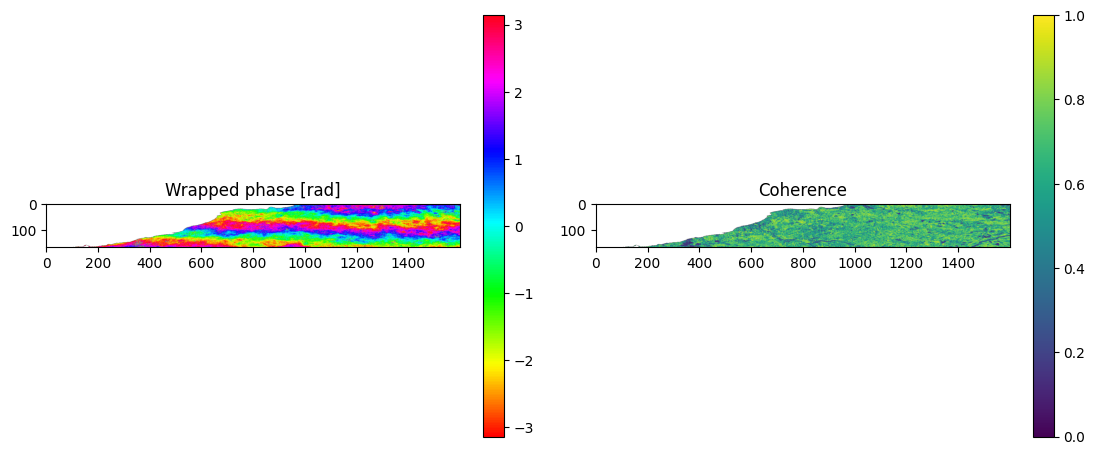

In [6]:
p_wrapped = ProductIO.readProduct(wrapped_out)
print('Bands:', [b.getName() for b in p_wrapped.getBands()])
plot_interferogram(p_wrapped)
p_wrapped.dispose()

---
## ***Part 2 — Export to SNAPHU format***
---

`SnaphuExport` writes the wrapped phase, coherence and a `snaphu.conf` config file into a directory that SNAPHU can read directly. The exported phase/coh bands are byte-for-byte the inputs SNAPHU expects.

In [7]:
g_export = Graph()
g_export.add_node(operator=Operator('Read', file=wrapped_out), node_id='Read')
g_export.add_node(operator=Operator('SnaphuExport',
                                    targetFolder=snaphu_dir,
                                    statCostMode='DEFO',
                                    initMethod='MCF',
                                    numberOfTileRows='1',
                                    numberOfTileCols='1',
                                    numberOfProcessors='1',
                                    rowOverlap='200',
                                    colOverlap='200'),
                  node_id='SnaphuExport', source='Read')

run_graph(g_export, os.path.join(graphs_dir, 'snap_nb_insar_snaphu_export.xml'))

# Find the subdirectory SnaphuExport created
exported_subdirs = [d for d in os.listdir(snaphu_dir)
                    if os.path.isdir(os.path.join(snaphu_dir, d))]
print('SnaphuExport wrote into:', exported_subdirs)
snaphu_work_dir = os.path.join(snaphu_dir, exported_subdirs[0])
print('Working directory:', snaphu_work_dir)

graph OK: snap_nb_insar_snaphu_export.xml
SnaphuExport wrote into: ['snap_nb_insar_wrapped']
Working directory: E:\ESA\snap-jupyter-notebooks\resources\jupyter_notebooks\snaphu\snap_nb_insar_wrapped


---
## ***Part 3 — Run SNAPHU***
---

SNAPHU reads `snaphu.conf` from the working directory and writes an unwrapped `.img` file. We invoke it via `subprocess` here.

In [8]:
import subprocess

if not run_snaphu:
    print(f"SNAPHU executable '{SNAPHU_BIN}' not found on PATH - skipping Part 3 (unwrapping) and "
          "Part 4. SNAPHU has no native Windows build; install it (Linux/macOS or WSL) and re-run.")
else:
    # SnaphuExport writes snaphu.conf with the exact command line SNAPHU needs in a header comment.
    conf_path = os.path.join(snaphu_work_dir, 'snaphu.conf')
    # SnaphuExport can leave an empty correlation-file stem (CORRFILE = '.snaphu.img'), which makes
    # snaphu abort with "Can't open file .snaphu.img". Repair it to the exported coherence raster.
    import re, glob
    _conf = open(conf_path).read()
    _coh = glob.glob(os.path.join(snaphu_work_dir, 'coh_*.snaphu.img'))
    if _coh and re.search(r'(?m)^CORRFILE\s+\.snaphu\.img\s*$', _conf):
        _conf = re.sub(r'(?m)^(CORRFILE\s+).*$', lambda m: m.group(1) + os.path.basename(_coh[0]), _conf)
        open(conf_path, 'w').write(_conf)
        print('patched CORRFILE ->', os.path.basename(_coh[0]))
    with open(conf_path, 'r') as f:
        head = ''.join([next(f) for _ in range(20)])
    print('--- snaphu.conf header (first 20 lines) ---'); print(head)
    import re
    match = re.search(r'^#\s*snaphu\s+(.+)$', head, re.MULTILINE)
    if match is None:
        raise RuntimeError('Could not find suggested snaphu command line in snaphu.conf')
    snaphu_args = match.group(1).split()
    print(f'Will invoke ({snaphu_mode}): snaphu ' + ' '.join(snaphu_args))
    result = run_snaphu_in(snaphu_work_dir, snaphu_args)
    print('STDOUT:'); print(result.stdout[-1500:])
    print('STDERR:'); print(result.stderr[-1500:])
    if result.returncode != 0:
        raise RuntimeError(f'snaphu exited with code {result.returncode}')

patched CORRFILE -> coh_IW1_VV_09Aug2014_21Aug2014.snaphu.img
--- snaphu.conf header (first 20 lines) ---
# CONFIG FOR SNAPHU
# ---------------------------------------------------------------- 
# Created by SNAP software on: 16:50:18 10/06/2026
#
# Command to call snaphu:
# 
#       snaphu -f snaphu.conf Phase_ifg_VV_09Aug2014_21Aug2014.snaphu.img 8000

#########################
# Unwrapping parameters #
#########################

STATCOSTMODE 	 DEFO 
INITMETHOD  	 MCF 
VERBOSE 	 TRUE 

###############
# Input files #
###############


Will invoke (wsl): snaphu -f snaphu.conf Phase_ifg_VV_09Aug2014_21Aug2014.snaphu.img 8000


STDOUT:
Treesize: 6365686    Pivots: 6270        Improvements: 504        Treesize: 6375912    Pivots: 6275        Improvements: 504        Treesize: 6381025    Pivots: 6278        Improvements: 504        Treesize: 6386138    Pivots: 6280        Improvements: 504        Treesize: 6386138    Pivots: 6281        Improvements: 504        Treesize: 6391202    Pivots: 6282        Improvements: 504        Treesize: 6391202    Pivots: 6282        Improvements: 504        
Current solution cost: 71198049
Maximum valid flow on network: 2
Flow increment: 2  (Total improvements: 504)
Found 1 valid set(s) of

---
## ***Part 4 — Import unwrapped phase, convert to displacement, geocode***
---

`SnaphuImport` reads the unwrapped `.img` SNAPHU produced and adds an `Unw_Phase_*` band back into the SNAP product. From there:

- **PhaseToDisplacement** scales the unwrapped phase to metres of line-of-sight (LOS) displacement using the radar wavelength.
- **Terrain-Correction** finally puts the displacement map in a map projection.

In [9]:
if not run_snaphu:
    print('Skipping Part 4 (SnaphuImport -> displacement) because SNAPHU did not run.')
else:
    import glob
    unw_hdrs = (glob.glob(os.path.join(snaphu_work_dir, 'UnwPhase*.hdr'))
                or [h for h in glob.glob(os.path.join(snaphu_work_dir, '*.hdr'))
                    if 'unw' in os.path.basename(h).lower()])
    if not unw_hdrs:
        raise FileNotFoundError(f'No unwrapped .hdr in {snaphu_work_dir} - did snaphu run?')
    unwrapped_hdr = unw_hdrs[0]; print('Unwrapped phase header:', unwrapped_hdr)

    g_disp = Graph()
    g_disp.add_node(operator=Operator('Read', file=wrapped_out), node_id='ReadWrapped')
    g_disp.add_node(operator=Operator('Read', file=unwrapped_hdr), node_id='ReadUnwrapped')
    g_disp.add_node(operator=Operator('SnaphuImport', doNotKeepWrapped='false'),
                    node_id='SnaphuImport', source=['ReadWrapped', 'ReadUnwrapped'])
    g_disp.add_node(operator=Operator('PhaseToDisplacement'), node_id='Disp', source='SnaphuImport')
    g_disp.add_node(operator=Operator('Terrain-Correction', demName='Copernicus 30m Global DEM',
                                      mapProjection='WGS84(DD)', pixelSpacingInMeter='20',
                                      imgResamplingMethod='BILINEAR_INTERPOLATION'),
                    node_id='TC', source='Disp')
    displacement_out = os.path.join(results_dir, 'snap_nb_insar_displacement.dim')
    g_disp.add_node(operator=Operator('Write', file=displacement_out, formatName='BEAM-DIMAP'),
                    node_id='Write', source='TC')
    run_graph(g_disp, os.path.join(graphs_dir, 'snap_nb_insar_displacement.xml'))

Unwrapped phase header: E:\ESA\snap-jupyter-notebooks\resources\jupyter_notebooks\snaphu\snap_nb_insar_wrapped\UnwPhase_ifg_VV_09Aug2014_21Aug2014.snaphu.hdr


graph OK: snap_nb_insar_displacement.xml


Bands: ['displacement_VV']


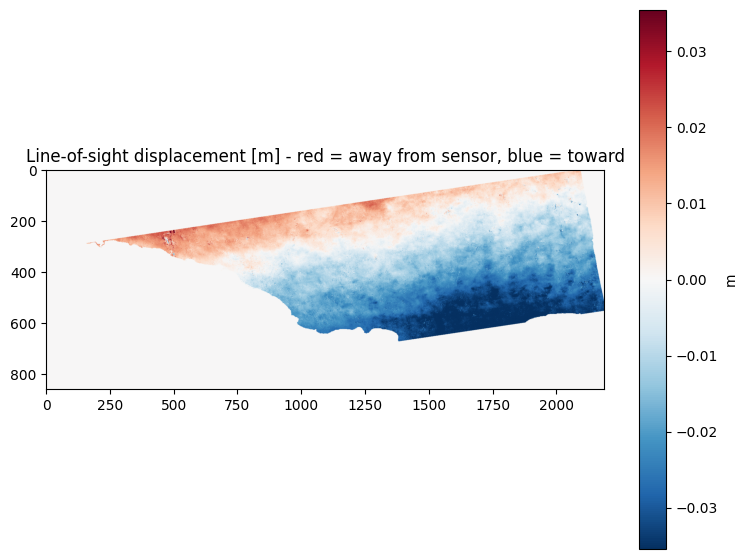

In [10]:
if run_snaphu:
    p_disp = ProductIO.readProduct(displacement_out)
    print('Bands:', [b.getName() for b in p_disp.getBands()])
    disp_band = find_band(p_disp, 'displacement', 'Displacement')
    data = _read_band(p_disp, disp_band)
    vmax = np.nanpercentile(np.abs(data), 98)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title('Line-of-sight displacement [m] - red = away from sensor, blue = toward')
    fig.colorbar(im, ax=ax, label='m')
    plt.show()
    p_disp.dispose()

---

### ***Summary***

What have we learnt in this notebook?

- The classical Sentinel-1 IW InSAR chain has ≈10 GPF operators and one external tool (SNAPHU) for the unwrapping step.
- Phase unwrapping turns the wrapped (mod-2π) fringe pattern into an absolute phase field. SNAPHU's `DEFO` cost mode + `MCF` initialiser is a reasonable default for deformation studies.
- `PhaseToDisplacement` scales unwrapped phase by `-λ / (4π)` to give line-of-sight displacement in metres.
- The whole chain ends with `Terrain-Correction` so the displacement map is in a map projection ready for GIS.
- This is the *classical* path. The companion notebook [snap-nb-sar-gslc-insar](snap-nb-sar-gslc-insar.ipynb) shows the shorter GSLC alternative for the geocoded-complex case.